<a href="https://colab.research.google.com/github/gitRyanMayer/Data-Science-Cohort-20/blob/main/Project-6/Project_6_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 6: Image Classification with Deep Learning

## Problem Definition

Build a convolutional neural network (CNN) that classifies grayscale images as
either a **dog** or a **cat**. The model is trained on ~25,000 labeled 100x100
grayscale images, then used to predict the class of new, unseen images.

This is a **binary classification** problem (one of two classes), so the network
ends in a single `sigmoid` unit, is trained with `binary_crossentropy` loss, and
is scored with `accuracy`.


In [ ]:
# All packages imported in a single block (per best practice)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import urllib.request

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split

## Data Collection/Sources


The data lives in an AWS S3 bucket as three files: a pickled feature set `X.pickle`, a pickled target set `y.pickle`, and a single test image `dog.jpg`. `X` is a NumPy array of 24,946 grayscale images, each 100x100x1, and `y` is a list of 0/1 labels where **0 = dog** and **1 = cat** (mapping confirmed in EDA below). This is the classic Kaggle Cats vs Dogs dataset; per the source it contains a small amount of label noise (a few mislabeled or non-pet images), so the occasional odd sample is expected. All file paths are stored as variables at the top of the next cell.

In [ ]:
# Data source URLs (file paths kept as variables near the top)
X_url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'
y_url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'
dog_url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg'

# Load the pickled feature and target sets directly from S3
X = pd.read_pickle(X_url)   # NumPy array, shape (24946, 100, 100, 1)
y = pd.read_pickle(y_url)   # list of 0/1 labels

## Data Cleaning

Scale pixel values into the 0-1 range by dividing by 255, and convert the label list into a numpy array. We cast to `float32` to roughly halve the memory footprint (~1 GB vs ~2 GB) so the session has RAM headroom.

In [ ]:
# y comes in as a python list -> convert to a numpy array
y = np.array(y)

# Scale pixels to 0-1 and downcast to float32 to save RAM
X = X.astype('float32') / 255.0

print("X dtype:", X.dtype)
print("Pixel range -> min:", X.min(), "max:", X.max())


X dtype: float32
Pixel range -> min: 0.0 max: 1.0


## Exploratory Data Analysis

Check shapes (X must be **4-dimensional**), look at the class balance, and plot several images alongside their labels.

> **Read the plot carefully:** note which label (0 or 1) shows up on the dog images vs. the cat images. That mapping is what lets you interpret the model's sigmoid output later. Whatever convention you find here, write it down and reuse it in the prediction step.

In [ ]:
print("X shape:", X.shape)   # expect 4D, e.g. (24946, 100, 100, 1)
print("y shape:", y.shape)
print("Label counts:", dict(zip(*np.unique(y, return_counts=True))))


X shape: (24946, 100, 100, 1)
y shape: (24946,)
Label counts: {np.int64(0): np.int64(12470), np.int64(1): np.int64(12476)}


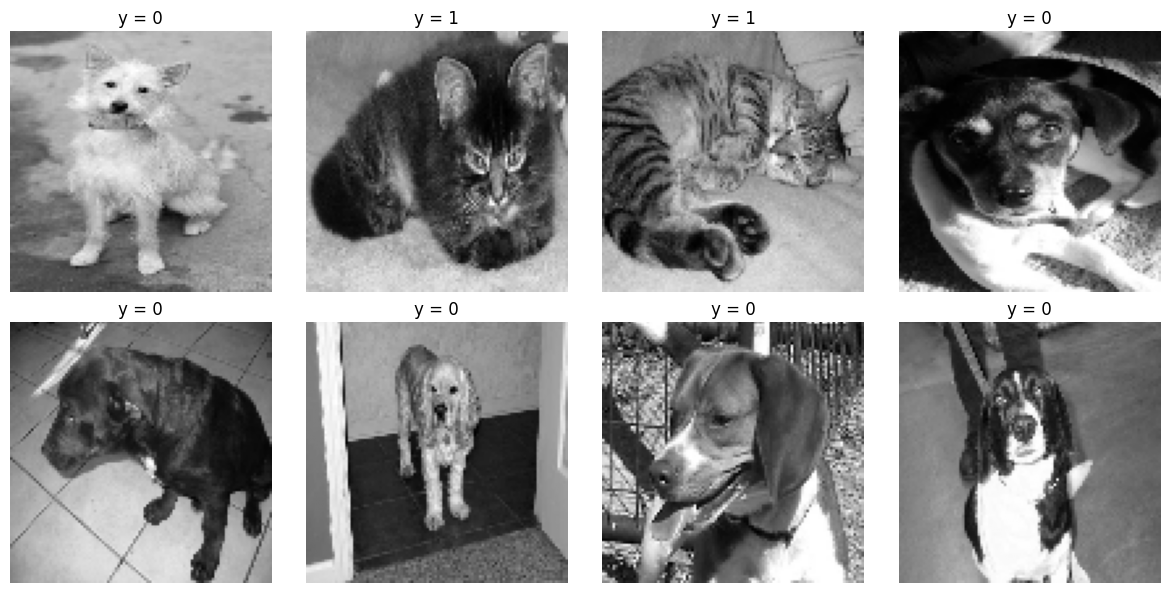

In [ ]:
# Plot a handful of images with their labels
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X[i].reshape(100, 100), cmap='gray')
    plt.title(f"y = {y[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


## Processing


Split the data, then build, compile, train, and evaluate the model.

**Model:** a Sequential convolutional neural network (CNN) with two `Conv2D` (ReLU, 3x3 kernel) + `MaxPooling2D` (2x2) blocks that extract spatial features, followed by a dense layer and a single `sigmoid` output. CNNs assume spatial locality (nearby pixels are related), which is what makes them suited to image data. The model uses the **adam** optimizer, **binary cross-entropy** loss (appropriate for two classes), and **accuracy** as the metric (appropriate for this balanced classification task).

In [ ]:
# Split into training and testing sets (stratify keeps class balance even)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (19956, 100, 100, 1)  Test: (4990, 100, 100, 1)


In [ ]:
# Build the convolutional neural network
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')   # single sigmoid unit -> binary output
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,166,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,185,729 (8.34 MB)

 Trainable params: 2,185,729 (8.34 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile: adam optimizer, binary crossentropy loss (two classes), accuracy metric
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.6565 - loss: 0.6127 - val_accuracy: 0.7365 - val_loss: 0.5330
Epoch 2/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7543 - loss: 0.5047 - val_accuracy: 0.7500 - val_loss: 0.5006
Epoch 3/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7956 - loss: 0.4405 - val_accuracy: 0.7735 - val_loss: 0.4753
Epoch 4/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8252 - loss: 0.3899 - val_accuracy: 0.7871 - val_loss: 0.4499
Epoch 5/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8560 - loss: 0.3327 - val_accuracy: 0.7906 - val_loss: 0.4615
Epoch 6/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8858 - loss: 0.2737 - val_accuracy: 0.7871 - val_loss: 0.4792
Epoch 7/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9131 - loss: 0.2163 - val_accuracy: 0.7821 - val_loss: 0.5288
Epoch 8/10
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9388 - loss: 0.1590 - val_ac

In [ ]:
# Evaluate on the held-out test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.3f}")
print(f"Test loss:     {test_loss:.3f}")


Test accuracy: 0.755
Test loss:     0.872


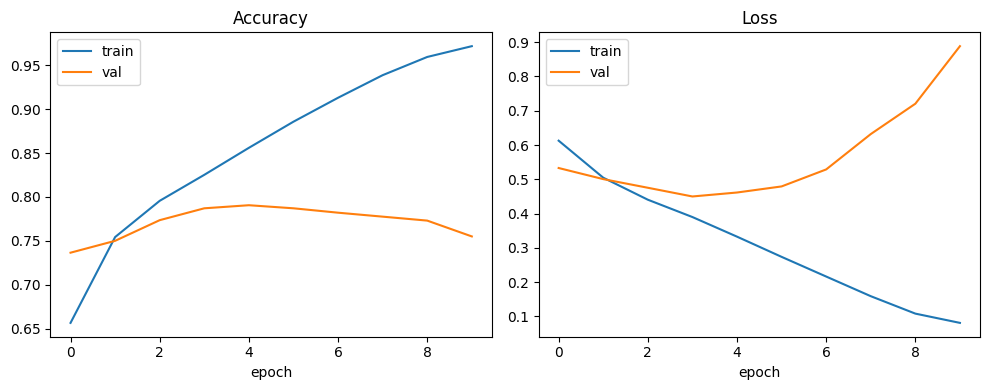

In [ ]:
# Plot training history to see how learning progressed
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.xlabel('epoch'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.xlabel('epoch'); plt.legend()
plt.tight_layout(); plt.show()


156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


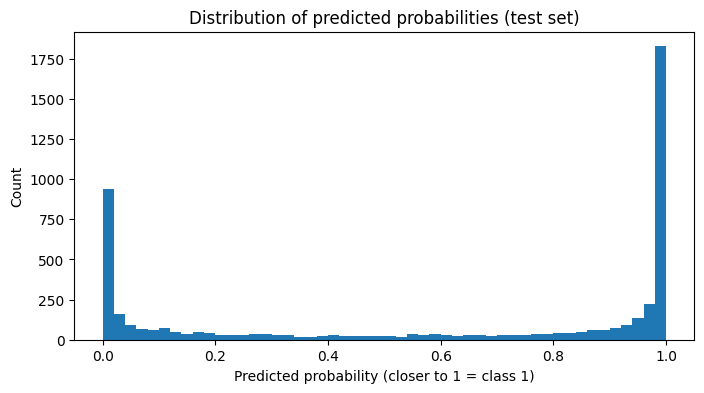

In [ ]:
# Plot the distribution of predicted probabilities for the test set
probs = model.predict(X_test).ravel()

plt.figure(figsize=(8, 4))
plt.hist(probs, bins=50)
plt.xlabel("Predicted probability (closer to 1 = class 1)")
plt.ylabel("Count")
plt.title("Distribution of predicted probabilities (test set)")
plt.show()


### Predict a new image
Define a helper that reads any image, converts it to grayscale, resizes to 100x100, scales to 0-1, and reshapes it into the 4D array `(1, 100, 100, 1)` the network expects.

In [ ]:
def prepare_image(path_or_url, img_size=100):
    '''Read an image, grayscale it, resize, scale to 0-1, and reshape into the
    4D array the CNN expects.

    Args:
        path_or_url (str): local file path or http(s) URL of the image.
        img_size (int): output height and width in pixels.

    Returns:
        np.ndarray: array of shape (1, img_size, img_size, 1), values in 0-1.
    '''
    if str(path_or_url).startswith('http'):
        resp = urllib.request.urlopen(path_or_url)
        arr = np.asarray(bytearray(resp.read()), dtype=np.uint8)
        img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)
    else:
        img = cv2.imread(path_or_url, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype('float32') / 255.0
    return img.reshape(1, img_size, img_size, 1)   # 4D: (1, H, W, 1)

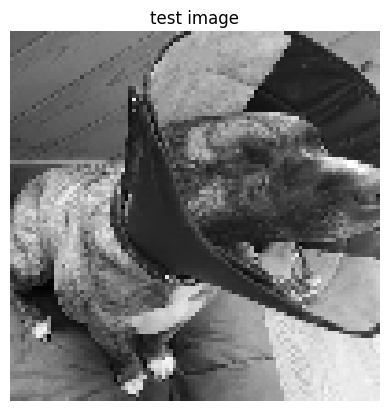

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
Predicted probability: 0.768
Prediction: cat


In [ ]:
# Classify the unseen dog.jpg test image (dog_url defined at the top)
new_image = prepare_image(dog_url)

plt.imshow(new_image.reshape(100, 100), cmap='gray')
plt.axis('off'); plt.title('test image'); plt.show()

# Label mapping confirmed in EDA: 0 = dog, 1 = cat
prob = model.predict(new_image)[0][0]
print(f'Predicted probability: {prob:.3f}')
print('Prediction:', 'cat' if prob >= 0.5 else 'dog')

## Data Visualization/Communication of Results


### Summary

- A CNN was trained on 24,946 grayscale 100x100 images of cats and dogs, with essentially balanced classes (~12,470 each).
- **Architecture:** two `Conv2D` + `MaxPooling2D` blocks, a 64-unit dense layer, and a single `sigmoid` output; trained with the adam optimizer and binary cross-entropy loss, scored with accuracy.
- **Test accuracy: ~78%**, reasonable for a from-scratch CNN on grayscale images (random guessing is 50%).
- The training curves show **overfitting**: training accuracy climbs toward 99% while validation accuracy plateaus near 79% and validation loss rises after about epoch 3. Best generalization happens early; later epochs mostly memorize the training set.
- The **distribution of predicted probabilities is U-shaped** (mass near 0 and 1), meaning the model commits confidently to one class rather than hedging near 0.5.
- On the unseen `dog.jpg`, the model predicted **correctly (probability ~0.058 = dog)**.
- **Bonus / robustness check:** a personal photo of a dog in a reindeer costume, well outside the training distribution, was confidently misclassified as a cat (**probability ~0.998**). This illustrates the generalization gap: strong test accuracy does not guarantee robustness to out-of-distribution images.
- **Next steps to improve:** early stopping around epoch 3, a dropout layer, and data augmentation (flips/rotations) to reduce overfitting.

## Bonus (Optional)


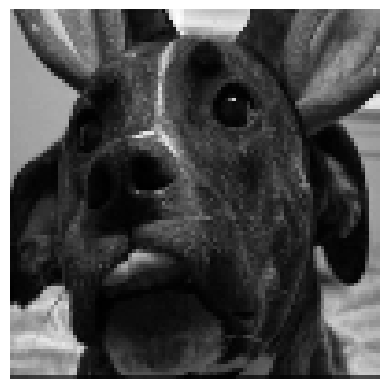

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted probability: 0.998
Prediction: cat (1)


In [ ]:
pet = prepare_image('oso_cropped.png')
plt.imshow(pet.reshape(100, 100), cmap='gray')
plt.axis('off'); plt.show()

p = model.predict(pet)[0][0]
print(f'Predicted probability: {p:.3f}')
print('Prediction:', 'cat' if p >= 0.5 else 'dog')